In [12]:
import pandas as pd
import geopandas as gpd
import numpy as np
import xyzservices

## read in, basic stats

In [13]:
daily = gpd.read_parquet('./test_stops_2026-06-10.parquet').rename(columns={'agency': 'analysis_name'})

In [14]:
monthly = gpd.read_parquet('./test_stops_monthly_2026-06-01.parquet')

In [15]:
daily.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 82670 entries, 0 to 82669
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   analysis_name       79957 non-null  object  
 1   stop_id             82670 non-null  object  
 2   stop_name           82670 non-null  object  
 3   n_routes            82670 non-null  int64   
 4   route_ids_served    82670 non-null  object  
 5   route_types_served  82670 non-null  object  
 6   n_arrivals          82670 non-null  int64   
 7   n_hours_in_service  82670 non-null  int64   
 8   meters_to_shn       82670 non-null  float64 
 9   base64_url          82670 non-null  object  
 10  district_name       82670 non-null  object  
 11  geometry            82670 non-null  geometry
dtypes: float64(1), geometry(1), int64(3), object(7)
memory usage: 7.6+ MB


In [16]:
monthly.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 89548 entries, 0 to 89547
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   name                        89548 non-null  object  
 1   stop_id                     89548 non-null  object  
 2   stop_name                   89548 non-null  object  
 3   geometry                    89548 non-null  geometry
 4   routetypes                  89548 non-null  object  
 5   route_ids_served            89548 non-null  object  
 6   n_hours_in_service          89548 non-null  float64 
 7   n_arrivals                  89548 non-null  int32   
 8   n_routes                    89548 non-null  int64   
 9   meters_to_ca_state_highway  89548 non-null  float64 
 10  analysis_name               89548 non-null  object  
 11  district_name               89548 non-null  object  
dtypes: float64(2), geometry(1), int32(1), int64(1), object(7)
memory u

<Axes: >

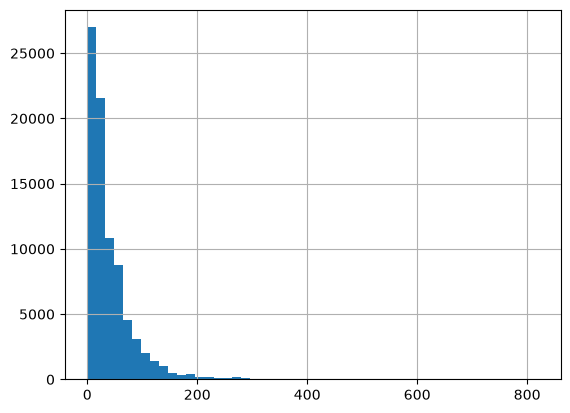

In [17]:
daily.n_arrivals.hist(bins=50)

<Axes: >

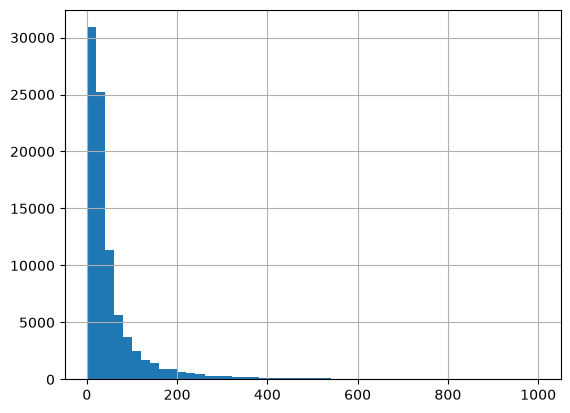

In [18]:
monthly_sub_1000 = monthly[monthly.n_arrivals <= 1000] # for display
monthly_sub_1000.n_arrivals.hist(bins=50)

## Join daily to monthly

In [19]:
monthly_to_join = monthly.copy()[['analysis_name', 'stop_id', 'n_arrivals']]

In [20]:
compare = pd.merge(daily, monthly_to_join, on=['analysis_name', 'stop_id'], suffixes=('', '_monthly'))
compare = compare[compare.n_arrivals > 0]
compare['monthly_daily_ratio'] = compare.n_arrivals_monthly / compare.n_arrivals
compare['monthly_daily_ratio_log'] = np.log(compare.monthly_daily_ratio)
compare = compare.round(3)

In [21]:
# compare.sort_values(by='monthly_daily_ratio')

In [22]:
compare.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 77357 entries, 0 to 81062
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   analysis_name            77357 non-null  object  
 1   stop_id                  77357 non-null  object  
 2   stop_name                77357 non-null  object  
 3   n_routes                 77357 non-null  int64   
 4   route_ids_served         77357 non-null  object  
 5   route_types_served       77357 non-null  object  
 6   n_arrivals               77357 non-null  int64   
 7   n_hours_in_service       77357 non-null  int64   
 8   meters_to_shn            77357 non-null  float64 
 9   base64_url               77357 non-null  object  
 10  district_name            77357 non-null  object  
 11  geometry                 77357 non-null  geometry
 12  n_arrivals_monthly       77357 non-null  int32   
 13  monthly_daily_ratio      77357 non-null  float64 
 14  mon

In [23]:
compare.describe()

,n_routes,n_arrivals,n_hours_in_service,meters_to_shn,n_arrivals_monthly,monthly_daily_ratio,monthly_daily_ratio_log
count,77357.000000,77357.000000,77357.000000,7.735700e+04,77357.000000,77357.000000,77357.000000
mean,1.382965,42.863012,15.211073,4.447327e+04,69.075947,1.357791,0.148106
std,0.993943,46.056503,5.580649,3.487893e+05,179.085945,2.857799,0.426889
min,1.000000,1.000000,1.000000,0.000000e+00,1.000000,0.153000,-1.879000
25%,1.000000,15.000000,13.000000,3.415000e+02,15.000000,0.919000,-0.085000
50%,1.000000,29.000000,16.000000,8.378000e+02,29.000000,1.000000,0.000000
75%,1.000000,58.000000,19.000000,1.681400e+03,62.000000,1.222000,0.201000
max,29.000000,820.000000,24.000000,4.035497e+06,8798.000000,418.000000,6.035000


## Mapping

In [38]:
import branca
cmap = branca.colormap.linear.PuOr_05
cmap = cmap.scale(-2, 2)
cmap.text_color = 'white'
cmap

colormap should center on zero (daily monthly equal), then fan out

In [28]:
to_map = compare[['n_arrivals', 'n_arrivals_monthly', 'monthly_daily_ratio',
                           'monthly_daily_ratio_log', 'analysis_name', 'route_ids_served',
                             'geometry']]

In [29]:
to_map.analysis_name.value_counts()[:10]

analysis_name
Los Angeles County Metropolitan Transportation Authority            12002
Orange County Transportation Authority                               5069
Alameda-Contra Costa Transit District                                4425
San Diego Metropolitan Transit System, Airport, Flagship Cruises     4130
City and County of San Francisco                                     3257
Santa Clara Valley Transportation Authority                          3148
City of Los Angeles                                                  2781
OmniTrans                                                            2284
Riverside Transit Agency                                             2121
Foothill Transit                                                     1982
Name: count, dtype: int64

In [30]:
to_map.analysis_name.value_counts()[:10].index

Index(['Los Angeles County Metropolitan Transportation Authority',
       'Orange County Transportation Authority',
       'Alameda-Contra Costa Transit District',
       'San Diego Metropolitan Transit System, Airport, Flagship Cruises',
       'City and County of San Francisco',
       'Santa Clara Valley Transportation Authority', 'City of Los Angeles',
       'OmniTrans', 'Riverside Transit Agency', 'Foothill Transit'],
      dtype='object', name='analysis_name')

In [31]:
top_10_agencies = to_map.analysis_name.value_counts()[:10].index

In [32]:
in_top_10 = to_map[to_map.analysis_name.isin(top_10_agencies)]

In [33]:
out_top_10 = to_map[~to_map.analysis_name.isin(top_10_agencies)]

In [ ]:
in_top_10.explore(column='monthly_daily_ratio_log', cmap=cmap, tiles=xyzservices.providers.CartoDB.DarkMatter)

In [35]:
# out_top_10.head(15000).explore(column='monthly_daily_ratio_log', cmap=cmap)

22